# Preprocesamiento

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')

In [20]:
df = pd.read_csv(r"C:\Users\Daniel Herrera\Documents\Personal\MCD\Tesis\Datos Tesis\Data_Crimes_2001.csv")

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,1917210,HH100082,12/31/2001 11:58:00 PM,0000X N OGDEN AV,0810,THEFT,OVER $500,STREET,False,False,...,NaN,NaN,06,1166017.0,1900248.0,2001,08/17/2015 03:03:40 PM,41.881864,-87.665847,"(41.88186382, -87.665846779)"
1,1917250,HH100172,12/31/2001 11:55:00 PM,043XX S PULASKI RD,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,NaN,NaN,14,1150352.0,1875802.0,2001,08/17/2015 03:03:40 PM,41.815101,-87.724006,"(41.815100864, -87.724005581)"
2,1919150,HH100019,12/31/2001 11:55:00 PM,047XX S HALSTED ST,1310,CRIMINAL DAMAGE,TO PROPERTY,STREET,True,False,...,NaN,NaN,14,1171721.0,1873672.0,2001,08/17/2015 03:03:40 PM,41.808813,-87.645683,"(41.808813388, -87.645683302)"
3,1918303,HH100166,12/31/2001 11:55:00 PM,032XX W FULLERTON AV,041A,BATTERY,AGGRAVATED: HANDGUN,STREET,False,False,...,NaN,NaN,04B,1154518.0,1915816.0,2001,08/17/2015 03:03:40 PM,41.924821,-87.707654,"(41.924821484, -87.707654064)"
4,1918312,HH100067,12/31/2001 11:55:00 PM,022XX S LEAVITT ST,0420,BATTERY,AGGRAVATED:KNIFE/CUTTING INSTR,STREET,False,False,...,NaN,NaN,04B,1162083.0,1889354.0,2001,08/17/2015 03:03:40 PM,41.852053,-87.680597,"(41.852052718, -87.680596503)"


In [7]:
columns = ['Date', 'Primary Type', 'District', 'Domestic', 'Arrest']
df = df[columns].copy()

In [9]:
# Eliminar valores faltantes en variables clave
df = df.dropna(subset=['Date', 'Primary Type', 'District', 'Domestic', 'Arrest'])

# Convertir Arrest a binario
df['Arrest'] = df['Arrest'].astype(int)

# Convertir fecha especificando formato explícito
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m/%d/%Y %I:%M:%S %p',   # Formato del dataset Chicago
    errors='coerce'                 # Convierte errores a NaT en vez de romper el código
)

# Eliminar posibles fechas mal parseadas
df = df.dropna(subset=['Date'])

# Extraer variables temporales
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Lunes, 6=Domingo

df.head()

,Date,Primary Type,District,Domestic,Arrest,Year,Month,Hour,DayOfWeek
0,2001-12-31 23:58:00,THEFT,12,False,0,2001,12,23,0
1,2001-12-31 23:55:00,CRIMINAL DAMAGE,8,False,0,2001,12,23,0
2,2001-12-31 23:55:00,CRIMINAL DAMAGE,9,False,1,2001,12,23,0
3,2001-12-31 23:55:00,BATTERY,14,False,0,2001,12,23,0
4,2001-12-31 23:55:00,BATTERY,10,False,0,2001,12,23,0


# PARTE A – ANÁLISIS DE DEPENDENCIA

## Tabla de contingencia – Primary Type vs Arrest

In [10]:
cont_primary = pd.crosstab(df['Primary Type'], df['Arrest'])
cont_primary.head()

Arrest,0,1
Primary Type,,
ARSON,830,181
ASSAULT,24236,7151
BATTERY,73005,20466
BURGLARY,24319,1695
CONCEALED CARRY LICENSE VIOLATION,0,1


## Prueba Chi-cuadrado

In [11]:
chi2, p, dof, expected = chi2_contingency(cont_primary)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 204810.4525907648
p-value: 0.0


## Cramér’s V

In [12]:
n = cont_primary.sum().sum()
phi2 = chi2 / n
r, k = cont_primary.shape
cramers_v_primary = np.sqrt(phi2 / min(k-1, r-1))

print("Cramér's V (Primary Type):", cramers_v_primary)

Cramér's V (Primary Type): 0.6492052942382114


## Repetir para District

In [13]:
cont_district = pd.crosstab(df['District'], df['Arrest'])
chi2_d, p_d, _, _ = chi2_contingency(cont_district)

n_d = cont_district.sum().sum()
phi2_d = chi2_d / n_d
r_d, k_d = cont_district.shape
cramers_v_district = np.sqrt(phi2_d / min(k_d-1, r_d-1))

print("p-value District:", p_d)
print("Cramér's V (District):", cramers_v_district)

p-value District: 0.0
Cramér's V (District): 0.13429271410080834


# PARTE B – INFORMACIÓN MUTUA

## Preparar datos para MI

In [14]:
df_mi = df.copy()

le = LabelEncoder()

df_mi['Primary Type'] = le.fit_transform(df_mi['Primary Type'])
df_mi['District'] = le.fit_transform(df_mi['District'])
df_mi['Domestic'] = df_mi['Domestic'].astype(int)

X = df_mi[['Primary Type', 'District', 'Domestic', 'Month', 'Hour']]
y = df_mi['Arrest']

## Calcular Mutual Information

In [15]:
mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information': mi
}).sort_values(by='Mutual Information', ascending=False)

mi_df

,Feature,Mutual Information
0,Primary Type,0.229418
1,District,0.010962
2,Domestic,0.009415
4,Hour,0.007662
3,Month,0.005943


## Visualización

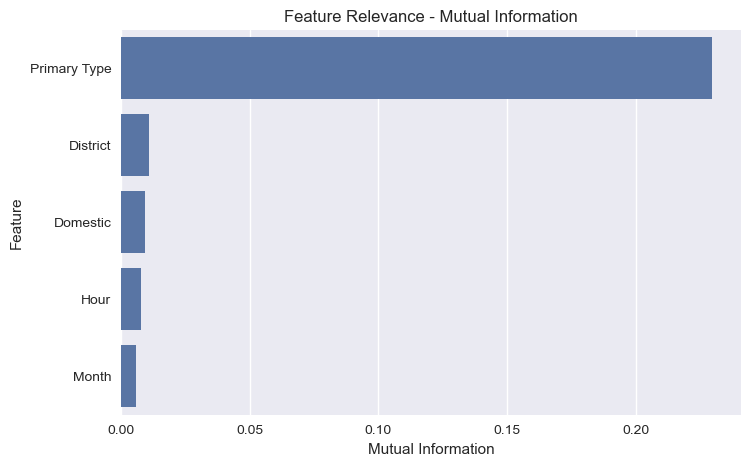

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=mi_df, x='Mutual Information', y='Feature')
plt.title("Feature Relevance - Mutual Information")
plt.show()

# PARTE C – ANÁLISIS DESCRIPTIVO DIRIGIDO

In [17]:
prob_arrest = df.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False)

prob_arrest.head(10)

Primary Type
CONCEALED CARRY LICENSE VIOLATION    1.000000
DOMESTIC VIOLENCE                    1.000000
OTHER NARCOTIC VIOLATION             1.000000
OBSCENITY                            1.000000
PUBLIC INDECENCY                     1.000000
NARCOTICS                            0.999842
PROSTITUTION                         0.999502
LIQUOR LAW VIOLATION                 0.999389
GAMBLING                             0.996788
WEAPONS VIOLATION                    0.827489
Name: Arrest, dtype: float64

## Heatmap District vs Arrest Rate

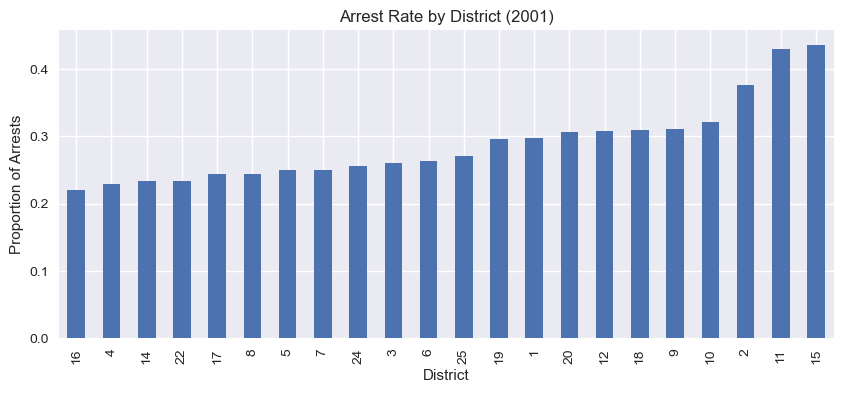

In [18]:
district_arrest = df.groupby('District')['Arrest'].mean()

plt.figure(figsize=(10,4))
district_arrest.sort_values().plot(kind='bar')
plt.title("Arrest Rate by District (2001)")
plt.ylabel("Proportion of Arrests")
plt.show()

# PARTE D – RANKING FINAL DE VARIABLES

In [19]:
results = pd.DataFrame({
    'Feature': ['Primary Type', 'District'],
    'Cramers_V': [cramers_v_primary, cramers_v_district]
})

results

,Feature,Cramers_V
0,Primary Type,0.649205
1,District,0.134293


# Interpretación
El análisis de asociación reveló que la variable Primary Type presenta una fuerte relación con la ocurrencia de arresto (Cramér’s V = 0.649), mientras que District mostró una asociación débil (Cramér’s V = 0.134).
La medida de Información Mutua confirmó que Primary Type es el predictor más relevante, reduciendo significativamente la incertidumbre del evento Arrest.
Las variables temporales mostraron baja contribución individual en el análisis univariado.
Con estos resultados:

Primary Type debe estar en todos los modelos

District podría incluirse para evaluar mejora marginal

Variables temporales pueden ser útiles en modelos no lineales